# Лабораторная работа 1 - Machine Unlearning

## Сбор данных

In [37]:
import re
import time
import feedparser
import pandas as pd
import requests

Этим запрос ищем точную фразу `machine unlearning` в названии или аннотации публикации arXiv

In [38]:
API_URL = "https://export.arxiv.org/api/query"
DATE_FROM = "2020-01-01T00:00:00Z"
DATE_TO = "2026-09-20T21:47:00Z"
MIN_PUBLICATIONS = 300
PAGE_SIZE = 100
REQUEST_PAUSE = 3.3

start_time = pd.Timestamp(DATE_FROM)
end_time = pd.Timestamp(DATE_TO)
SEARCH_QUERY = (
    '(ti:"machine unlearning" OR abs:"machine unlearning") '
    f'AND submittedDate:[{start_time.strftime("%Y%m%d%H%M")} '
    f'TO {end_time.strftime("%Y%m%d%H%M")}]'
)

### Выгрузка через arXiv API

API возвращает Atom/XML. `fetch_page` получает страницу и общее число результатов, а следующий цикл проходит по всем страницам. Из записи сохраняются ID версии и статьи, название, авторы, аннотация, даты, ссылка и категории. Версия удаляется из `arxiv_id`, чтобы обновления одной работы не считались разными публикациями

In [39]:
def fetch_page(start):
    params = {
        "search_query": SEARCH_QUERY,
        "start": start,
        "max_results": PAGE_SIZE,
        "sortBy": "submittedDate",
        "sortOrder": "ascending",
    }
    time.sleep(REQUEST_PAUSE)
    response = requests.get(API_URL, params=params, timeout=60)
    response.raise_for_status()
    feed = feedparser.parse(response.content)
    total = int(feed.feed["opensearch_totalresults"])
    return feed.entries, total


In [40]:
records = []
start = 0
total = None
raw_df = df = None

while total is None or start < total:
    entries, page_total = fetch_page(start)
    if total is None:
        total = page_total
        if total < MIN_PUBLICATIONS:
            raise ValueError("найдено меньше 300 работ")

    if not entries and start < total:
        raise RuntimeError(
            f"Неполная выгрузка arXiv: пустая страница при cursor={start}, total={total}."
        )

    for entry in entries:
        version_id = entry.get("id", "").rstrip("/").rsplit("/", 1)[-1]
        arxiv_id = re.sub(r"v\d+$", "", version_id)
        records.append({
            "arxiv_id": arxiv_id,
            "version_id": version_id,
            "title": entry.get("title", ""),
            "authors": [author.get("name", "") for author in entry.get("authors", [])],
            "abstract": entry.get("summary", ""),
            "published": entry.get("published", ""),
            "updated": entry.get("updated", ""),
            "url": f"https://arxiv.org/abs/{arxiv_id}",
            "categories": [tag.get("term", "") for tag in entry.get("tags", [])],
        })

    start += len(entries)
    print(f"Получено {len(records)} / {total}")


Получено 100 / 858
Получено 200 / 858
Получено 300 / 858
Получено 400 / 858
Получено 500 / 858
Получено 600 / 858
Получено 700 / 858
Получено 800 / 858
Получено 858 / 858


### Очистка корпуса

Приводим пробелы в текстах к одному виду, даты - к UTC. Исключаем записи без корректного ID, названия, аннотации или авторов и записи вне заданного периода. Проверки ниже подтверждают размер корпуса, уникальность ID и обязательные поля

In [91]:
raw_df = pd.DataFrame(records)
df = raw_df.copy()

def compact_spaces(text):
    return " ".join(str(text or "").split())

for column in ("title", "abstract"):
    df[column] = df[column].map(compact_spaces)
df["authors"] = df["authors"].map(
    lambda names: [compact_spaces(name) for name in names if compact_spaces(name)]
)
for column in ("published", "updated"):
    df[column] = pd.to_datetime(df[column], utc=True, errors="coerce")

valid = (
    df["arxiv_id"].str.fullmatch(r"\d{4}\.\d{4,5}")
    & df["title"].ne("")
    & df["abstract"].ne("")
    & df["authors"].map(len).gt(0)
    & df["published"].between(start_time, end_time)
)
df = (
    df.loc[valid]
    .sort_values(["updated", "version_id"], na_position="first")
    .drop_duplicates("arxiv_id", keep="last")
    .sort_values(["published", "arxiv_id"])
    .reset_index(drop=True)
)
print(f"Получено: {len(raw_df)}; исключено: {len(raw_df) - len(df)}; осталось: {len(df)}")

Получено: 858; исключено: 0; осталось: 858


In [92]:
assert len(df) >= MIN_PUBLICATIONS, "меньше 300 публикаций"
assert df["arxiv_id"].is_unique, "есть повторные ID"
assert df["title"].str.strip().ne("").all(), "есть пустые названия"
assert df["abstract"].str.strip().ne("").all(), "есть пустые аннотации"
assert df["authors"].map(lambda names: bool(names) and all(names)).all(), "не заполнены авторы"
assert df["published"].between(start_time, end_time).all(), "есть даты вне периода"
print("Проверки корпуса пройдены")

Проверки корпуса пройдены


## Разведочный анализ корпуса текстов

Тексты корпуса - названия и аннотации публикаций. Для подсчета длины и частот разбиваем названия и аннотации на токены

In [93]:
from collections import Counter
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def tokenize(text):
    return re.findall(r"[a-z]+", text.lower())

eda_df = df.copy(deep=True)
eda_df["year"] = eda_df["published"].dt.year
eda_df["title_tokens"] = eda_df["title"].fillna("").map(tokenize)
eda_df["abstract_tokens"] = eda_df["abstract"].fillna("").map(tokenize)
eda_df["title_length"] = eda_df["title_tokens"].map(len)
eda_df["abstract_length"] = eda_df["abstract_tokens"].map(len)
eda_df["tokens"] = eda_df["title_tokens"] + eda_df["abstract_tokens"]

### Публикации по годам

2026 год отмечент звездочкой тк еще не завершен и еще может быть дополнен

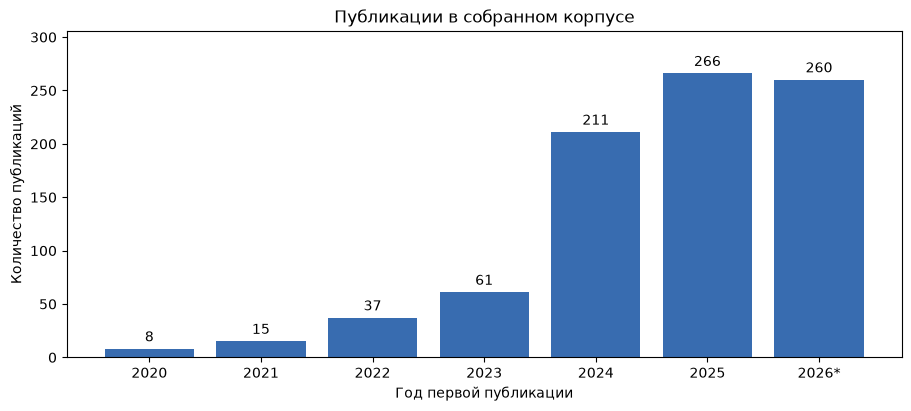

Больше всего работ в выборке за 2025: 266


In [94]:
first_year = pd.Timestamp(DATE_FROM).year
cutoff = pd.Timestamp(DATE_TO)
year_counts = eda_df["year"].value_counts().reindex(
    range(first_year, cutoff.year + 1), fill_value=0
).sort_index()
last_year_end = pd.Timestamp(f"{cutoff.year + 1}-01-01", tz="UTC") - pd.Timedelta(minutes=1)
partial_last_year = cutoff < last_year_end

fig, ax = plt.subplots(figsize=(9, 4), layout="constrained")
bars = ax.bar(year_counts.index, year_counts.values, color="#386CB0")
ax.bar_label(bars, padding=3)
ax.set_xticks(year_counts.index, [
    f"{year}*" if partial_last_year and year == cutoff.year else str(year)
    for year in year_counts.index
])
ax.set(title="Публикации в собранном корпусе", xlabel="Год первой публикации",
       ylabel="Количество публикаций", ylim=(0, max(1, year_counts.max()) * 1.15))
plt.show()

peak_years = ", ".join(map(str, year_counts.index[year_counts.eq(year_counts.max())]))
print(f"Больше всего работ в выборке за {peak_years}: {year_counts.max()}")

### Длины текстов

Длина названия и аннотации измеряется числом токенов

Первый квартиль - короче этой длины 25% текстов

Третий квартиль - короче этой длины 75% текстов

,"Название, токены","Аннотация, токены"
Минимум,2.0,82.0
Первый квартиль,7.0,164.0
Медиана,9.5,193.0
Среднее,9.5,193.4
Третий квартиль,12.0,222.0
Максимум,21.0,304.0


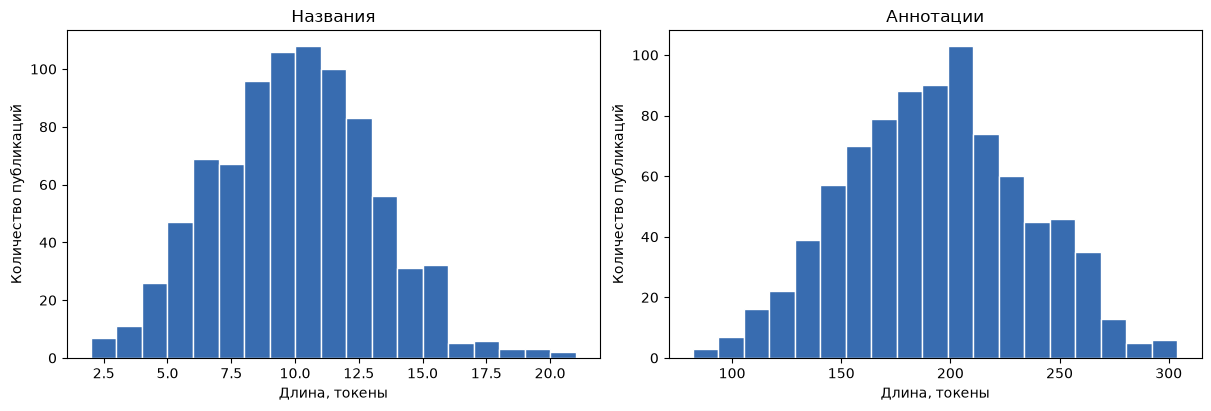

Три самые короткие аннотации


,title,abstract_length,url
500,Analise de Desaprendizado de Maquina em Modelo...,82,https://arxiv.org/abs/2508.18509
504,Unleashing Uncertainty: Efficient Machine Unle...,85,https://arxiv.org/abs/2508.20773
12,A unified PAC-Bayesian framework for machine u...,93,https://arxiv.org/abs/2106.00265


Три самые длинные аннотации


,title,abstract_length,url
111,Machine Unlearning in Learned Databases: An Ex...,304,https://arxiv.org/abs/2311.17276
23,Zero-Shot Machine Unlearning,299,https://arxiv.org/abs/2201.05629
20,Fast Yet Effective Machine Unlearning,298,https://arxiv.org/abs/2111.08947


In [47]:
length_stats = eda_df[["title_length", "abstract_length"]].describe().loc[
    ["min", "25%", "50%", "mean", "75%", "max"]
].rename(
    index={"min": "Минимум", "25%": "Первый квартиль", "50%": "Медиана",
           "mean": "Среднее", "75%": "Третий квартиль", "max": "Максимум"},
    columns={"title_length": "Название, токены", "abstract_length": "Аннотация, токены"},
)
display(length_stats.round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), layout="constrained")
for ax, column, title in zip(axes, ["title_length", "abstract_length"], ["Названия", "Аннотации"]):
    ax.hist(eda_df[column], bins="auto", color="#386CB0", edgecolor="white")
    ax.set(title=title, xlabel="Длина, токены", ylabel="Количество публикаций")
plt.show()

for label, sample in [
    ("Три самые короткие аннотации", eda_df.nsmallest(3, "abstract_length")),
    ("Три самые длинные аннотации", eda_df.nlargest(3, "abstract_length")),
]:
    print(label)
    display(sample[["title", "abstract_length", "url"]])


### Частоты слов

Корпусная частота - число вхождений токена во всех текстах

Документная - число статей, где он встретился хотя бы раз

$N$ обозначает общее число вхождений токенов, $V$ - число различных токенов (размер словаря)

Во втором топе частых слов исключаются слова из готового словаря стоп-слов scikit-learn

Ранг - место слова в частотном словаре (словарь сортируется по частоте, чем выше частота тем ниже ранг)

In [49]:
word_counts = Counter()
document_counts = Counter()
for tokens in eda_df["tokens"]:
    word_counts.update(tokens)
    document_counts.update(set(tokens))

word_stats = pd.DataFrame([
    {"word": word, "frequency": frequency, "document_frequency": document_counts[word]}
    for word, frequency in word_counts.items()
]).sort_values(["frequency", "word"], ascending=[False, True]).reset_index(drop=True)
word_stats["rank"] = range(1, len(word_stats) + 1)

n_tokens = sum(word_counts.values())
vocabulary_size = len(word_counts)
hapax_count = int(word_stats["frequency"].eq(1).sum())
display(pd.DataFrame({
    "показатель": ["Всего токенов N", "Различных слов V", "Слов с частотой 1", "Их доля среди V, %"],
    "значение": [n_tokens, vocabulary_size, hapax_count, round(100 * hapax_count / vocabulary_size, 1)],
}))


,показатель,значение
0,Всего токенов N,174123.0
1,Различных слов V,8305.0
2,Слов с частотой 1,2706.0
3,"Их доля среди V, %",32.6


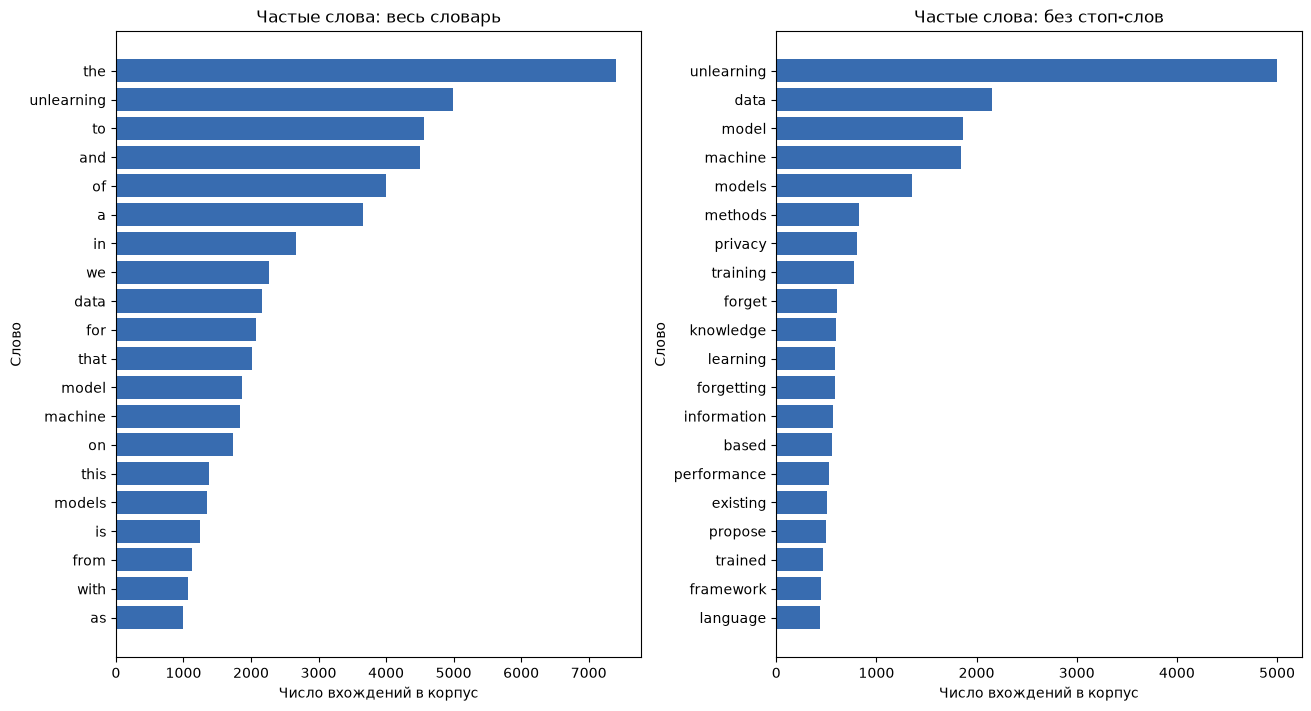

In [95]:
top_words = word_stats.head(20)
content_words = word_stats.loc[~word_stats["word"].isin(ENGLISH_STOP_WORDS)]
top_content = content_words.head(20)

fig, axes = plt.subplots(1, 2, figsize=(13, 7), layout="constrained")
for ax, table, title in zip(axes, [top_words, top_content], ["Частые слова: весь словарь", "Частые слова: без стоп-слов"]):
    ax.barh(table["word"], table["frequency"], color="#386CB0")
    ax.invert_yaxis()
    ax.set(title=title, xlabel="Число вхождений в корпус", ylabel="Слово")
plt.show()

### Проверка закона Ципфа

Закон Ципфа описывает типичное распределение слов в больших текстовых корпусах

$$f(r) \approx \frac{C}{r^s}, \qquad s \approx 1$$

- r - ранг слова
- f(r) - частота слова с этим рангом
- C - некоторое начальное значение частоты (частота самого часто встречаемого слова)
- s - параметр, описывающий скорость уменьшения частоты

На осях log–log она выглядит примерно прямой: $\log f(r) \approx \log C-s\log r$

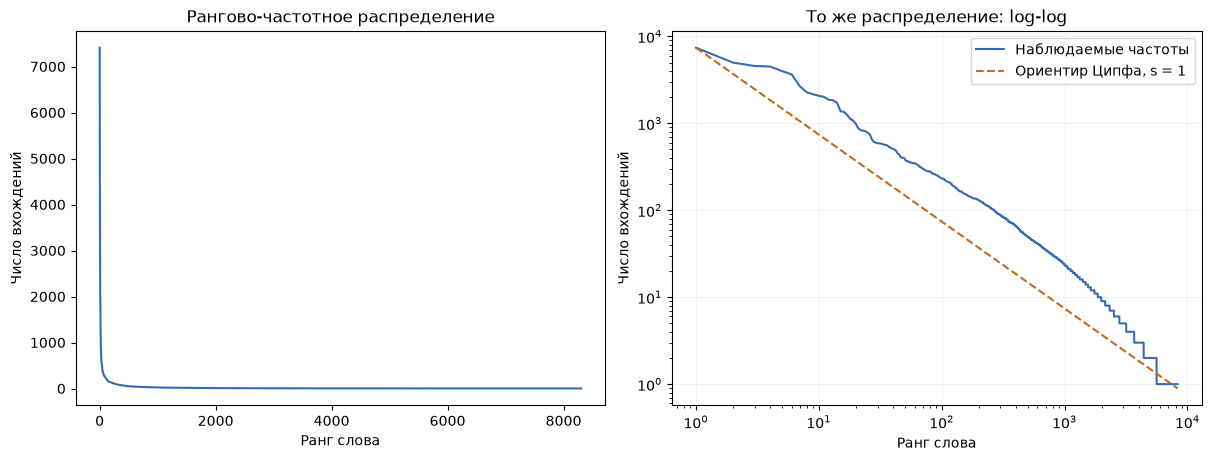

In [100]:
ranks = word_stats["rank"]
frequencies = word_stats["frequency"]
zipf_reference = frequencies.iloc[0] / ranks
point_marker = "o" if vocabulary_size == 1 else None

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), layout="constrained")
axes[0].plot(ranks, frequencies, color="#386CB0", linewidth=1.5, marker=point_marker)
axes[0].set(title="Рангово-частотное распределение", xlabel="Ранг слова", ylabel="Число вхождений")
axes[1].loglog(ranks, frequencies, color="#386CB0", linewidth=1.5, marker=point_marker, label="Наблюдаемые частоты")
axes[1].loglog(ranks, zipf_reference, "--", color="#C66A1B", label="Ориентир Ципфа, s = 1")
axes[1].set(title="То же распределение: log-log", xlabel="Ранг слова", ylabel="Число вхождений")
axes[1].legend()
axes[1].grid(alpha=0.25, which="major")
plt.show()

### Выводы по корпусу

Корпус содержит 858 публикаций (в период с 7 февраля 2020 по 18 сентября 2026). Число работ увеличивается от 8 в 2020 до 266 в 2025, особенно заметен рост между 2023 и 2024. За неполный 2026 собрано 260 статей

Обычно название содержит 9-10 токенов, медианная длина аннотации — 193. Средняя длина аннотации почти совпадает с медианой, крайние значения — 82 и 304 токена

В общем частотном списке заметны `the`, `to`, `and`, а после удаления стоп-слов — `data`, `model`, `privacy`, `training`

Распределение частот имеет резкий спад и длинный хвост. На log–log графике средние ранги напоминают прямую, но вся кривая изгибается и на большей части диапазона лежит выше ориентира. Это приблизительное сходство с законом Ципфа. Последняя ступень соответствует словам с единственным вхождением

## Выделение ключевых слов

Для каждой публикации по TF-IDF (TF - Term Frequency - насколько часто термин встречается в конкретной статье, IDF - Inverse Document Frequency - насколько редко этот термин встречается в остальных статьях) выбираем до десяти ключевых слов и словосочетаний: униграмм, биграмм и триграмм (из одного, двух и трех слов)

Лемматизацию (приведение разных форм слова к одной) выполняет spaCy `en_core_web_sm`

In [57]:
import math
from sklearn.feature_extraction.text import TfidfVectorizer
import spacy

kw_nlp = spacy.load("en_core_web_sm", disable=["ner"])

KW_MAX_NGRAM = 3
KW_MIN_DF = 2
KW_MAX_DF = 0.9
KW_TOP_K = 10
KW_SUBLINEAR_TF = True
KW_SMOOTH_IDF = True
KW_NORM = "l2"

### Нормализация текста

Для каждой публикации название и аннотация обрабатываются отдельно. Дефисы между буквами заменяются пробелами, после чего spaCy разбивает текст на предложения и приводит слова к начальной форме. Леммы переводятся в нижний регистр

Сохраняются английские слова длиной от двух букв. Стоп-слова, цифры и знаки препинания разрывают словосочетания, поэтому соседние слова через них не объединяются

Из последовательностей слов формируются униграммы, биграммы и триграммы. Повторные появления сохраняются для расчета TF

In [58]:
def kw_extract(text):
    prepared = re.sub(r"(?<=[A-Za-z])[-‐‑](?=[A-Za-z])", " ", text)
    parsed = kw_nlp(prepared)
    candidates, surfaces = [], {}
    for sentence in parsed.sents:
        tokens = list(sentence)
        for start in range(len(tokens)):
            lemmas = []
            for token in tokens[start:start + KW_MAX_NGRAM]:
                surface, lemma = token.text.lower(), token.lemma_.lower()
                if (not re.fullmatch(r"[A-Za-z]{2,}", token.text)
                        or not re.fullmatch(r"[a-z]{2,}", lemma)
                        or surface in ENGLISH_STOP_WORDS
                        or lemma in ENGLISH_STOP_WORDS):
                    break
                lemmas.append(lemma)
                term = " ".join(lemmas)
                candidates.append(term)
                fragment = text[tokens[start].idx:token.idx + len(token.text)]
                surfaces.setdefault(term, fragment)
    return candidates, surfaces


def kw_article_candidates(title, abstract):
    title_terms, surfaces = kw_extract(title)
    abstract_terms, abstract_surfaces = kw_extract(abstract)
    for term, surface in abstract_surfaces.items():
        surfaces.setdefault(term, surface)
    return title_terms + abstract_terms, surfaces


kw_documents, kw_surface_forms = [], []
for kw_title, kw_abstract in df[["title", "abstract"]].fillna("").itertuples(index=False, name=None):
    kw_candidates, kw_surfaces = kw_article_candidates(kw_title, kw_abstract)
    kw_documents.append(kw_candidates)
    kw_surface_forms.append(kw_surfaces)

print(f"Обработано публикаций: {len(kw_documents)}")


Обработано публикаций: 858


### Отбор терминов

Для каждого термина подсчитывается общее число появлений и количество публикаций, в которых он встретился. Остаются термины, найденные минимум в двух, но не более чем в 90% публикаций. Это позволяет исключить случайные и слишком распространенные выражения

In [105]:
def kw_count_candidates(documents):
    frequencies, document_frequencies = Counter(), Counter()
    for terms in documents:
        frequencies.update(terms)
        document_frequencies.update(set(terms))
    return pd.DataFrame([
        {"keyword": term, "frequency": count,
         "document_frequency": document_frequencies[term]}
        for term, count in frequencies.items()
    ], columns=["keyword", "frequency", "document_frequency"]).sort_values(
        ["frequency", "keyword"], ascending=[False, True]
    ).reset_index(drop=True)


kw_candidate_stats = kw_count_candidates(kw_documents)
document_frequency = kw_candidate_stats["document_frequency"]
max_document_frequency = KW_MAX_DF * len(kw_documents)
kw_allowed = document_frequency.between(KW_MIN_DF,max_document_frequency)

### Веса TF-IDF

TfidfVectorizer обрабатывает готовые списки терминов всего корпуса, поэтому словосочетания сохраняются как один признак

Для термина, присутствующего в публикации, рассчитываются:

$$
TF(t,d)=1+\ln c(t,d),
$$

$$
IDF(t)=\ln\left(\frac{1+D}{1+DF(t)}\right)+1,
$$

$$
w(t,d)=TF(t,d)\cdot IDF(t)
$$

- $t$ - термин
- $d$ - публикация
- $c(t,d)$ - число появлений термина $t$ в публикации $d$
- $D$ - общее число публикаций
- $DF(t)$ - число публикаций, содержащих термин $t$
- $\ln$ - натуральный логарифм
- $w(t,d)$ - исходный вес TF-IDF термина

TF увеличивает вес повторяющихся терминов, но ограничивает влияние большого числа повторов. IDF повышает вес терминов, характерных для небольшого числа публикаций, и уменьшает вес распространенных терминов

In [107]:
def kw_identity_analyzer(terms):
    return terms

def kw_fit_tfidf(documents):
    vectorizer = TfidfVectorizer(
        analyzer=kw_identity_analyzer,
        min_df=KW_MIN_DF, max_df=KW_MAX_DF,
        sublinear_tf=KW_SUBLINEAR_TF, smooth_idf=KW_SMOOTH_IDF, norm=KW_NORM,
    )
    return vectorizer, vectorizer.fit_transform(documents)

kw_vectorizer, kw_matrix = kw_fit_tfidf(kw_documents)
kw_terms = kw_vectorizer.get_feature_names_out()
assert set(kw_terms) == set(kw_candidate_stats.loc[kw_allowed, "keyword"])
print(f"Разреженная матрица: {kw_matrix.shape[0]} публикаций / {kw_matrix.shape[1]} терминов")

Разреженная матрица: 858 публикаций / 9767 терминов


### Ключевые слова в публикациях

Для каждой публикации термины с положительным весом TF-IDF сортируются по убыванию веса, а при равенстве по алфавиту. Первые десять терминов или все доступные, если их меньше, выбираются в качестве ключевых слов публикации

In [61]:
def kw_rank_row(row, terms, limit=KW_TOP_K):
    weighted = [(str(terms[index]), float(score))
                for index, score in zip(row.indices, row.data) if score > 0]
    return sorted(weighted, key=lambda pair: (-pair[1], pair[0]))[:limit]


kw_df_lookup = kw_candidate_stats.set_index("keyword")["document_frequency"].to_dict()
kw_lists, kw_detail_rows = [], []
for kw_position, kw_id in enumerate(df["arxiv_id"]):
    kw_ranked = kw_rank_row(kw_matrix.getrow(kw_position), kw_terms)
    kw_lists.append([term for term, score in kw_ranked])
    for kw_term, kw_score in kw_ranked:
        kw_detail_rows.append({
            "arxiv_id": kw_id, "keyword": kw_term,
            "surface_form": kw_surface_forms[kw_position][kw_term],
            "score": kw_score, "ngram_size": len(kw_term.split()),
            "document_frequency": kw_df_lookup[kw_term],
        })

keywords_df = df.copy(deep=True)
keywords_df["keywords"] = kw_lists
keyword_details = pd.DataFrame(kw_detail_rows, columns=[
    "arxiv_id", "keyword", "surface_form", "score", "ngram_size", "document_frequency",
])
kw_empty = keywords_df["keywords"].map(len).eq(0)
print(f"Публикаций без тегов: {kw_empty.sum()}")
if kw_empty.any():
    display(keywords_df.loc[kw_empty, ["arxiv_id", "title", "url"]].head(5))

Публикаций без тегов: 0


## Граф ключевых слов

Вершинами графа являются выбранные ключевые слова и словосочетания. Два тега соединяются ребром, если они назначены одной публикации. Вес ребра равен числу публикаций, в которых эта пара встретилась

In [66]:
from itertools import combinations
from textwrap import fill
import networkx as nx

def build_keyword_graph(publications):
    counts, pair_publications = Counter(), {}
    for article_id, terms in publications[["arxiv_id", "keywords"]].itertuples(index=False, name=None):
        unique_terms = sorted(set(terms))
        counts.update(unique_terms)
        for pair in combinations(unique_terms, 2):
            pair_publications.setdefault(pair, set()).add(article_id)

    graph = nx.Graph()
    for term in sorted(counts):
        graph.add_node(term, publication_count=counts[term])
    for (source, target), ids in sorted(pair_publications.items()):
        publication_ids = tuple(sorted(ids))
        graph.add_edge(source, target, weight=len(publication_ids), publication_ids=publication_ids)
    return graph


keyword_graph = build_keyword_graph(keywords_df)
keyword_edges = pd.DataFrame([
    {"source": min(source, target), "target": max(source, target),
     "weight": attributes["weight"], "publication_ids": attributes["publication_ids"]}
    for source, target, attributes in keyword_graph.edges(data=True)
], columns=["source", "target", "weight", "publication_ids"]).sort_values(
    ["weight", "source", "target"], ascending=[False, True, True]
).reset_index(drop=True)

### Окрестность ключевого слова

Полный граф слишком велик для наглядного отображения, поэтому отрисованы выбранный термин и до 20 его соседей с наибольшими весами связей. В подграфе сохраняются также связи соседей друг с другом

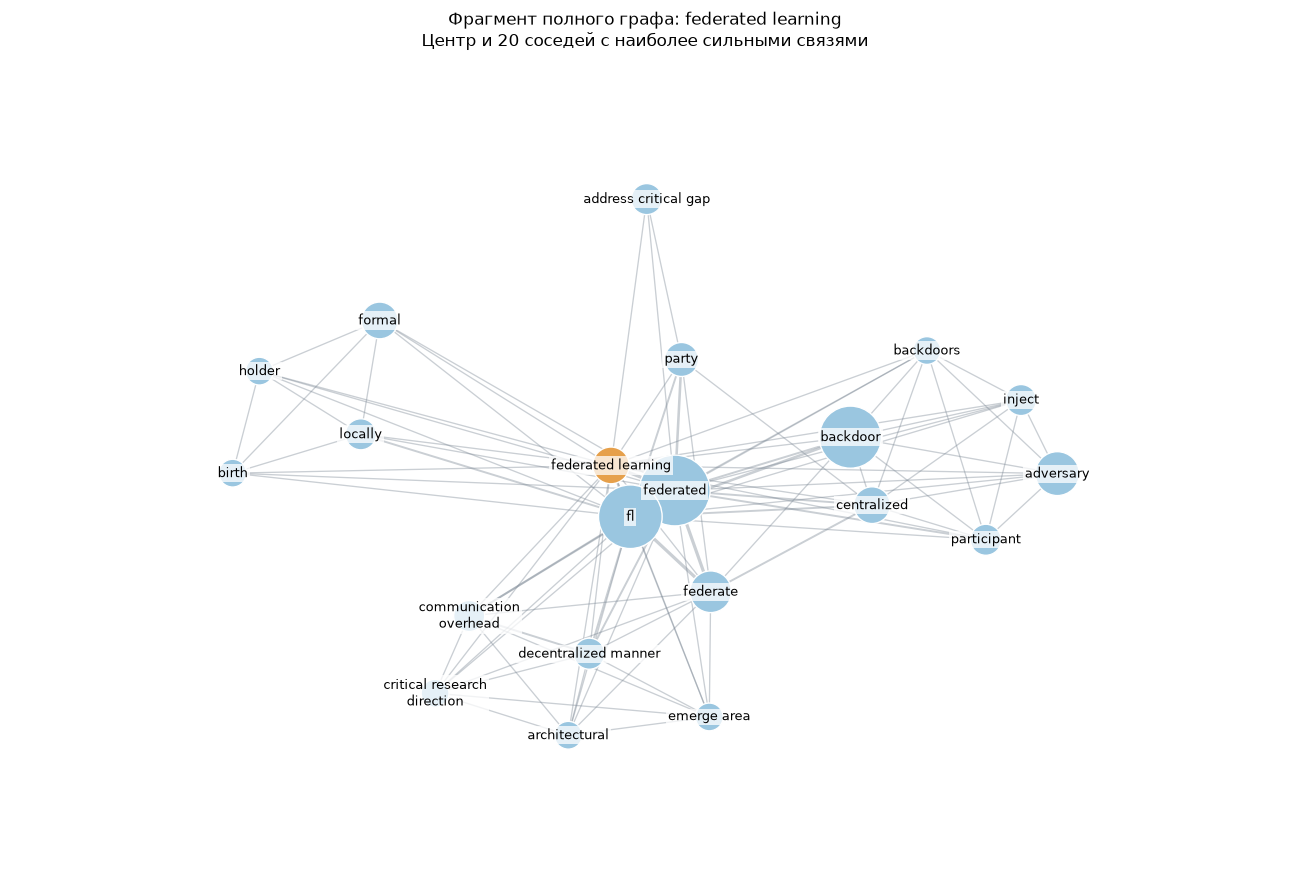

,keyword,weight,publication_count
0,federated,4,23
1,fl,3,18
2,address critical gap,1,2
3,adversary,1,7
4,architectural,1,1
5,backdoor,1,17
6,backdoors,1,1
7,birth,1,1
8,centralized,1,4
9,communication overhead,1,2


In [69]:
FOCUS_KEYWORD = "federated learning"
MAX_NEIGHBORS = 20
LAYOUT_SEED = 42


def select_keyword_neighborhood(graph, focus, max_neighbors=20):
    columns = ["keyword", "weight", "publication_count"]
    if focus not in graph:
        return nx.Graph(), pd.DataFrame(columns=columns)
    neighbors = sorted(graph.neighbors(focus), key=lambda term: (-graph[focus][term]["weight"], term))[:max_neighbors]
    table = pd.DataFrame([
        {"keyword": term, "weight": graph[focus][term]["weight"],
         "publication_count": graph.nodes[term]["publication_count"]}
        for term in neighbors
    ], columns=columns)
    subgraph = graph.subgraph([focus] + neighbors)
    view = nx.Graph()
    view.add_nodes_from((term, subgraph.nodes[term]) for term in sorted(subgraph))
    view.add_edges_from(sorted(
        (min(source, target), max(source, target), attributes)
        for source, target, attributes in subgraph.edges(data=True)
    ))
    return view, table


keyword_graph_view, kg_neighbors = select_keyword_neighborhood(keyword_graph, FOCUS_KEYWORD, MAX_NEIGHBORS)
kg_positions = {}
if FOCUS_KEYWORD not in keyword_graph:
    print(f"Термина '{FOCUS_KEYWORD}' нет среди выбранных тегов. Рисунок пропущен; выберите существующий FOCUS_KEYWORD.")
else:
    if kg_neighbors.empty:
        print(f"'{FOCUS_KEYWORD}' — изолированная вершина, соседей нет.")
    kg_positions = nx.spring_layout(keyword_graph_view, seed=LAYOUT_SEED, weight="weight", k=0.9, iterations=100)
    kg_figure, kg_axis = plt.subplots(figsize=(13, 9))
    nx.draw_networkx_edges(
        keyword_graph_view, kg_positions, ax=kg_axis,
        width=[0.5 + 0.45 * data["weight"] for _, _, data in keyword_graph_view.edges(data=True)],
        edge_color="#7B8794", alpha=0.4,
    )
    nx.draw_networkx_nodes(
        keyword_graph_view, kg_positions, ax=kg_axis,
        node_size=[300 + 100 * keyword_graph_view.nodes[term]["publication_count"] for term in keyword_graph_view],
        node_color=["#E6A04B" if term == FOCUS_KEYWORD else "#9AC6E0" for term in keyword_graph_view],
        edgecolors="white", linewidths=1,
    )
    nx.draw_networkx_labels(
        keyword_graph_view, kg_positions, ax=kg_axis,
        labels={term: fill(term, width=20, break_long_words=False, break_on_hyphens=False) for term in keyword_graph_view},
        font_size=9, bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.75, "pad": 1.5},
    )
    kg_axis.set_title(f"Фрагмент полного графа: {FOCUS_KEYWORD}\nЦентр и {len(kg_neighbors)} соседей с наиболее сильными связями")
    kg_axis.margins(0.2)
    kg_axis.set_axis_off()
    kg_figure.tight_layout()
    plt.show()
    display(kg_neighbors)

## Кластеризация графа ключевых слов

Цель кластеризации - найти группы ключевых слов, которые часто встречаются вместе в одних публикациях

Для поиска кластеров использовала алгоритм Louvain. Сначала каждая вершина рассматривается как отдельная группа. Затем алгоритм перемещает вершины между соседними группами, если это улучшает модулярность. Процесс повторяется до тех пор, пока дальнейшие перемещения перестают улучшать разбиение

In [109]:
from statistics import median
from sklearn.metrics import adjusted_rand_score
from matplotlib.patches import Patch

COMM_RESOLUTION = 1.0
COMM_SEED = 42
COMM_SEEDS = (0, 1, 2, 42, 100)


def detect_keyword_communities(graph, seed=42, resolution=1.0):
    ordered = nx.Graph()
    ordered.add_nodes_from(sorted(graph))
    ordered.add_weighted_edges_from(sorted(
        (min(source, target), max(source, target), data["weight"])
        for source, target, data in graph.edges(data=True)
    ))
    groups = nx.community.louvain_communities(
        ordered, weight="weight", resolution=resolution, seed=seed,
    )
    groups = sorted((frozenset(group) for group in groups), key=lambda group: (-len(group), tuple(sorted(group))))
    quality = nx.community.modularity(graph, groups, weight="weight", resolution=resolution)
    return groups, quality


keyword_communities, community_modularity = detect_keyword_communities(keyword_graph, COMM_SEED, COMM_RESOLUTION)
keyword_community_map = {
    term: community_id for community_id, group in enumerate(keyword_communities, 1) for term in sorted(group)
}
keyword_community_df = pd.DataFrame([
    {"keyword": term, "community_id": keyword_community_map[term],
     "publication_count": keyword_graph.nodes[term]["publication_count"]}
    for term in sorted(keyword_graph)
], columns=["keyword", "community_id", "publication_count"]).sort_values(
    ["community_id", "publication_count", "keyword"], ascending=[True, False, True]
).reset_index(drop=True)

print(f"Кластеров: {len(keyword_communities)}; модулярность Q = {community_modularity:.6f}.")

Кластеров: 33; модулярность Q = 0.555299.


### Оценка качества кластеризации

Кластеризацию оцениваем по двум характеристикам:

1. модулярность (показывает, насколько хорошо связи сосредоточены внутри найденных кластеров)
2. устойчивость (показывает, насколько похожие кластера получаются при повторных запусках)

#### Модулярность

Для взвешенного графа рассчитывается:

$$
Q=\sum_C\left[
\frac{W_C}{W}
-
\gamma\left(\frac{S_C}{2W}\right)^2
\right]
$$

Здесь:

- $Q$ - модулярность всего разбиения
- $C$ - кластер
- $W$ - сумма весов всех ребер графа
- $W_C$ - сумма весов ребер внутри кластера
- $S_C$ - сумма взвешенных степеней его вершин
- $\gamma$ - параметр разрешения, равный 1

Первая часть формулы показывает фактическую долю связей внутри кластера, а вторая - ожидаемую долю в случайной модели с похожей структурой графа. Чем больше сильных связей находится внутри кластеров по сравнению со случайным ожиданием, тем выше модулярность

#### Устойчивость

При разных значениях `seed` состав кластеров может изменяться. Для проверки алгоритм запускается с `seed = 0, 1, 2, 42, 100`, а каждый результат сравнивается с основным запуском `seed=42`

Сходство разбиений измеряется с помощью Adjusted Rand Index (ARI)

- `ARI = 1` - разбиения полностью совпадают
- `ARI` около 0 - сходство близко к случайному
- отрицательное значение - совпадение хуже случайного ожидания

ARI показывает согласованность разных запусков, а не точность относительно правильных тем, тк эталонной разметки кластеров нет

In [112]:
community_runs = {COMM_SEED: keyword_communities}
comm_modularities = {COMM_SEED: community_modularity}
comm_stability_rows = []
if community_modularity is not None:
    comm_node_order = sorted(keyword_graph)
    comm_reference_labels = [keyword_community_map[term] for term in comm_node_order]
    for comm_seed in COMM_SEEDS:
        if comm_seed not in community_runs:
            community_runs[comm_seed], comm_modularities[comm_seed] = detect_keyword_communities(
                keyword_graph, comm_seed, COMM_RESOLUTION,
            )
        comm_groups = community_runs[comm_seed]
        comm_labels = {term: i for i, group in enumerate(comm_groups) for term in group}
        comm_sizes = [len(group) for group in comm_groups]
        comm_stability_rows.append({
            "seed": comm_seed, "modularity": comm_modularities[comm_seed],
            "community_count": len(comm_groups), "min_size": min(comm_sizes),
            "median_size": median(comm_sizes), "max_size": max(comm_sizes),
            "ari_vs_42": adjusted_rand_score(comm_reference_labels, [comm_labels[t] for t in comm_node_order]),
        })
community_stability = pd.DataFrame(comm_stability_rows, columns=[
    "seed", "modularity", "community_count", "min_size", "median_size", "max_size", "ari_vs_42",
])

display(community_stability.round({"modularity": 6, "ari_vs_42": 4}))

,seed,modularity,community_count,min_size,median_size,max_size,ari_vs_42
0,0,0.553730,36,10,116.5,352,0.3122
1,1,0.553303,32,10,131.0,432,0.3183
2,2,0.554773,32,10,145.0,273,0.3187
3,42,0.555299,33,10,133.0,343,1.0000
4,100,0.554818,33,10,124.0,285,0.3843


### Состав и интерпретация кластеров

In [113]:
def summarize_keyword_communities(graph, communities):
    rows = []
    for community_id, group in enumerate(communities, 1):
        top_keywords = sorted(
            group,
            key=lambda term: (-graph.nodes[term]["publication_count"], term),
        )[:8]
        strongest_edges = sorted(
            (
                (min(source, target), max(source, target), data["weight"])
                for source, target, data in graph.subgraph(group).edges(data=True)
            ),
            key=lambda edge: (-edge[2], edge[0], edge[1]),
        )[:3]
        strong_pairs = [
            f"{source} — {target} ({weight})"
            for source, target, weight in strongest_edges
        ]
        rows.append({
            "community_id": community_id,
            "term_count": len(group),
            "top_keywords": top_keywords,
            "strong_pairs": strong_pairs,
        })
    return pd.DataFrame(
        rows,
        columns=["community_id", "term_count", "top_keywords", "strong_pairs"],
    )


community_summary = summarize_keyword_communities(keyword_graph, keyword_communities)


### Ключевые слова внутри кластеров

В таблице представлены все найденные кластеры. `top_keywords` характеризуют их содержание, а `strong_pairs` показывают пары терминов, которые чаще всего назначались одним публикациям


In [114]:
with pd.option_context("display.max_colwidth", None, "display.max_rows", None):
    display(community_summary.assign(
        top_keywords=community_summary["top_keywords"].map(", ".join),
        strong_pairs=community_summary["strong_pairs"].map("; ".join),
    ))


,community_id,term_count,top_keywords,strong_pairs
0,1,343,"multimodal, mllm, contrastive, representation, memorization, module, multimodal large, multimodal large language",multimodal large — multimodal large language (12); mllm — multimodal large (10); mllm — multimodal large language (10)
1,2,262,"diffusion, concept, diffusion model, multi, prompt, distillation, feature, domain",diffusion — diffusion model (11); concept — diffusion model (5); concept — target concept (5)
2,3,259,"mia, owner, distribution, auditing, membership, privacy risk, adversary, semantic",datum owner — owner (4); differential — differential privacy (4); membership — membership inference (4)
3,4,211,"continual, lora, cl, failure, interference, medical, phase, stability",continual — continual learning (5); continual — continual unlearning (5); cl — continual learning (4)
4,5,200,"federated, client, fl, federated unlearning, server, embed, recovery, user",federated — fl (14); federated — federated unlearning (11); client — federated (10)
5,6,195,"activation, noise, label, attribution, dnn, neuron, proxy, pruning",hoc — post hoc (6); attribution — datum attribution (3); corrective — corrective machine (3)
6,7,193,"graph, recommendation, fairness, recommender, sisa, graph unlearning, shard, complexity",graph — graph unlearning (8); recommendation — recommender (8); gnn — graph (7)
7,8,187,"generative, residual, adversarial, generative model, ai, reconstruction, corpus, fact",generative — generative model (7); generative — generative ai (4); ai — generative (3)
8,9,185,"backdoor, verification, defense, detection, clean, poison, poisoning, trigger",backdoor — trigger (6); backdoor — clean (5); asr — backdoor (3)
9,10,184,"certify, certify unlearning, instance, noisy, definition, convex, dp, shift",certify — certify unlearning (11); descent — gradient descent (4); certify — dp (3)


### Интерпретация основных кластеров

- **Кластер 1 - мультимодальные модели.** Основные термины: `multimodal`, `mllm`, `representation`, `multimodal large language`. Они часто встречаются вместе, хотя связь частично усиливается из-за вложенных словосочетаний
- **Кластер 2 - удаление концептов из диффузионных моделей.** В него вошли `diffusion`, `diffusion model`, `concept`, `target concept` и `prompt`. Эти термины объединены частым совместным использованием в публикациях
- **Кластер 3 - аудит приватности.** Характерные термины: `mia`, `membership`, `privacy risk`, `auditing` и `owner`. Они связаны с проверкой принадлежности данных обучающей выборке и оценкой рисков приватности
- **Кластер 4 - непрерывное обучение и адаптация моделей.** В группе находятся `continual`, `continual learning`, `lora`, `medical` и `clinical`. Кластер смешанный: он объединяет методы адаптации моделей и отдельные медицинские применения
- **Кластер 5 - федеративное забывание.** Основные термины: `federated`, `federated unlearning`, `client`, `server` и `fl`. Они часто встречаются вместе в публикациях об удалении вклада отдельных клиентов
- **Кластеры 32 и 33 - локальные группы.** Кластер 32 связан со сравнением методов забывания, а кластер 33 — с маскированием нейронов и устранением запоминания. Каждый из них сформирован тегами одной публикации, поэтому все связи имеют вес 1

В результате Louvain выделил несколько понятных тематических групп. Однако некоторые кластеры остаются смешанными, а похожие и вложенные выражения могут искусственно усиливать связи между терминами

### Выводы по кластеризации

1. При `seed=42` Louvain выделил 33 кластера размером от 10 до 343 терминов. Модулярность $Q=0{,}555299$ показывает, что внутренние связи кластеров выражены сильнее ожидаемых
2. При других значениях `seed` получается от 32 до 36 кластеров, модулярность меняется незначительно.
3. В крупнейших группах видны темы мультимодального, диффузионного и федеративного забывания, а также аудита приватности


## Анализ центральностей ключевых слов

Для каждого ключевого слова рассчитываются три показателя:

- **degree centrality** - количество непосредственных связей с другими терминами
- **betweenness centrality** - участие термина в кратчайших путях между другими вершинами
- **closeness centrality** - близость термина к остальным достижимым вершинам графа

In [ ]:
from copy import deepcopy
from time import perf_counter

KC_METRICS = ("degree_centrality", "betweenness_centrality", "closeness_centrality")
KC_LABELS = {
    "degree_centrality": "Degree centrality",
    "betweenness_centrality": "Взвешенная betweenness",
    "closeness_centrality": "Closeness: 1/w, поправка WF",
}


def prepare_centrality_graph(graph):
    weights = {
        int(attributes["weight"])
        for _, _, attributes in graph.edges(data=True)
    }
    scale = math.lcm(*sorted(weights)) if weights else 1

    result = nx.Graph()
    result.graph.update(deepcopy(graph.graph))
    result.add_nodes_from(
        (term, deepcopy(graph.nodes[term]))
        for term in sorted(graph)
    )

    for source, target in sorted(
        (min(u, v), max(u, v))
        for u, v in graph.edges()
    ):
        attributes = deepcopy(graph[source][target])
        attributes["distance"] = scale // int(attributes["weight"])
        result.add_edge(source, target, **attributes)

    return result, scale


centrality_graph, centrality_distance_scale = prepare_centrality_graph(
    keyword_graph
)

print(
    f"Полный граф: {len(centrality_graph):,} вершин, "
    f"{centrality_graph.number_of_edges():,} ребер; "
    f"L = {centrality_distance_scale}"
)


### Расчет центральностей

Для каждого ключевого слова рассчитываются три показателя.

**degree centrality:**

$$
C_D(v)=\frac{k(v)}{N-1},
$$

где $N$ — число вершин графа, а $k(v)$ - число разных соседей термина $v$. Показатель отражает долю терминов, связанных с ним напрямую. Веса ребер здесь не учитываются

**betweenness centrality:**

$$
C_B(v)=\frac{2}{(N-1)(N-2)}
\sum_{\substack{s<t\\s,t\ne v}}
\frac{\sigma_{st}(v)}{\sigma_{st}},
$$

где $\sigma_{st}$ - число кратчайших путей между вершинами $s$ и $t$, а $\sigma_{st}(v)$ - число таких путей, проходящих через $v$. Показатель отражает посредническую роль термина. Расчет выполняется для всех пар вершин, а начало и конец пути посредниками не считаются

**closeness centrality с поправкой Wasserman–Faust:**

$$
C_{WF}(v)=
\frac{r_v}{N-1}
\cdot
\frac{r_v}{\sum d(v,u)},
$$

где $r_v$ — число других вершин, достижимых из $v$, а $d(v,u)$ — длина кратчайшего пути от $v$ до $u$. Поправка $\frac{r_v}{N-1}$ уменьшает значение для терминов из небольших отдельных компонент графа

Для betweenness и closeness сила связи преобразуется в расстояние:

$$
\ell(u,v)=\frac{1}{w(u,v)},
$$

где $w(u,v)$ — число публикаций, в которых термины $u$ и $v$ выбраны вместе. Чем больше общий вес, тем короче расстояние между терминами

In [117]:
def calculate_keyword_centralities(graph, distance_scale, community_map):
    if len(graph) <= 1:
        degree_values = betweenness_values = closeness_values = {
            term: 0.0 for term in graph
        }
    else:
        degree_values = nx.degree_centrality(graph)
        betweenness_values = nx.betweenness_centrality(
            graph,
            k=None,
            normalized=True,
            weight="distance",
            endpoints=False,
        )
        closeness_values = {
            term: value * distance_scale
            for term, value in nx.closeness_centrality(
                graph,
                distance="distance",
                wf_improved=True,
            ).items()
        }

    component_sizes = {
        term: len(component)
        for component in nx.connected_components(graph)
        for term in component
    }

    rows = []
    for term in sorted(graph):
        rows.append({
            "keyword": term,
            "publication_count": graph.nodes[term]["publication_count"],
            "degree": graph.degree(term),
            "strength": graph.degree(term, weight="weight"),
            "degree_centrality": degree_values[term],
            "betweenness_centrality": betweenness_values[term],
            "closeness_centrality": closeness_values[term],
            "community_id": community_map[term],
            "component_size": component_sizes[term],
        })

    return pd.DataFrame(rows, columns=[
        "keyword",
        "publication_count",
        "degree",
        "strength",
        "degree_centrality",
        "betweenness_centrality",
        "closeness_centrality",
        "community_id",
        "component_size",
    ])


kc_started = perf_counter()

centrality_df = calculate_keyword_centralities(
    centrality_graph,
    centrality_distance_scale,
    keyword_community_map,
)

kc_elapsed = perf_counter() - kc_started

### Ключевые слова с наибольшими значениями центральности

In [118]:
CENTRALITY_TOP_N = 5
centrality_leaders = {}

for metric in KC_METRICS:
    leaders = (
        centrality_df
        .sort_values([metric, "keyword"], ascending=[False, True])
        .head(CENTRALITY_TOP_N)[
            ["keyword", metric, "publication_count", "degree", "community_id"]
        ]
        .reset_index(drop=True)
    )
    centrality_leaders[metric] = leaders

    print(KC_LABELS[metric])
    with pd.option_context("display.max_colwidth", None):
        display(leaders.round({metric: 6}))


Degree centrality


,keyword,degree_centrality,publication_count,degree,community_id
0,mu,0.052948,28,238,19
1,graph,0.039377,23,177,7
2,survey,0.037375,21,168,18
3,diffusion,0.033593,20,151,2
4,federated,0.033593,23,151,5


Взвешенная betweenness


,keyword,betweenness_centrality,publication_count,degree,community_id
0,mu,0.066452,28,238,19
1,survey,0.061215,21,168,18
2,multimodal,0.041446,19,135,1
3,federated,0.040635,23,151,5
4,concept,0.040059,19,148,2


Closeness: 1/w, поправка WF


,keyword,closeness_centrality,publication_count,degree,community_id
0,mu,0.475657,28,238,19
1,concept,0.475275,19,148,2
2,diffusion model,0.471850,18,141,2
3,federated,0.468662,23,151,5
4,fl,0.468059,18,119,5


### Интерпретация результатов

- По **degree centrality** выделяются `mu`, `graph`, `survey`, `diffusion` и `federated`. Эти термины имеют больше всего прямых связей с другими ключевыми словами. Это общие обозначения области или крупных направлений машинного забывания

- По **betweenness centrality** лидируют `mu`, `survey`, `multimodal`, `federated` и `concept`. Они часто находятся на кратчайших путях между другими терминами и связывают разные части графа

- По **closeness centrality** наибольшие значения имеют `mu`, `concept`, `diffusion model`, `federated` и `fl`. Они расположены близко к остальным вершинам благодаря частым и сильным связям внутри диффузионного и федеративного направлений

Термин `mu` имеет наибольшее значение всех трех центральностей. Это объясняется тем, что он используется как общее сокращение от *machine unlearning* и встречается в публикациях разных направлений

Таким образом, degree показывает широту непосредственных связей, betweenness - посредническую роль, а closeness - близость термина к остальной части графа

## Граф публикаций

Вершина графа соответствует публикации. Две публикации соединяются ребром, если у них есть хотя бы одно общее ключевое слово

Вес ребра равен числу общих тегов:

$$
w(A,B)=|K_A\cap K_B|,
$$

где $K_A$ и $K_B$ - множества ключевых слов публикаций $A$ и $B$

Для построения графа сначала создается соответствие ключевое слово - публикации. Затем для каждого ключевого слова формируются все пары публикаций, которым оно назначено. Если пара имеет несколько общих тегов, они накапливаются в `shared_keywords`, а их количество становится весом ребра

In [80]:
from collections import defaultdict

def build_publication_graph(publications):
    required = [
        "arxiv_id",
        "title",
        "abstract",
        "url",
        "keywords",
    ]

    graph = nx.Graph()
    tag_to_ids = defaultdict(set)

    for record in (
        publications[required]
        .sort_values("arxiv_id")
        .to_dict("records")
    ):
        paper_id = record["arxiv_id"]
        unique_tags = tuple(sorted(set(record["keywords"])))

        graph.add_node(
            paper_id,
            title=record["title"],
            abstract=record["abstract"],
            url=record["url"],
            keywords=unique_tags,
        )

        for tag in unique_tags:
            tag_to_ids[tag].add(paper_id)

    pair_to_tags = defaultdict(set)

    for tag in sorted(tag_to_ids):
        for pair in combinations(
            sorted(tag_to_ids[tag]),
            2,
        ):
            pair_to_tags[pair].add(tag)

    for (source, target), tags in sorted(pair_to_tags.items()):
        shared = tuple(sorted(tags))

        graph.add_edge(
            source,
            target,
            weight=len(shared),
            shared_keywords=shared,
        )

    return graph


publication_graph = build_publication_graph(keywords_df)

publication_edges = (
    pd.DataFrame(
        [
            (
                min(source, target),
                max(source, target),
                attributes["weight"],
                attributes["shared_keywords"],
            )
            for source, target, attributes
            in publication_graph.edges(data=True)
        ],
        columns=[
            "source",
            "target",
            "weight",
            "shared_keywords",
        ],
    )
    .astype({"weight": "int64"})
    .sort_values(
        ["weight", "source", "target"],
        ascending=[False, True, True],
        ignore_index=True,
    )
)

### Поиск публикаций по графу

Поиск выполняется в два этапа:

Функция `find_publications_by_title` ищет публикации по части названия без учета регистра и помогает определить `arxiv_id` исходной статьи

Функция `find_similar_publications` получает непосредственных соседей выбранной статьи в графе публикаций. Результаты сортируются по убыванию веса ребра, то есть числа общих ключевых слов. При одинаковом весе используется порядок `arxiv_id`

Для каждой найденной публикации выводятся название, ссылка, количество и список общих тегов. Поиск учитывает только непосредственные связи: если две статьи связаны только через промежуточную публикацию, они не считаются похожими

In [119]:
def find_publications_by_title(graph, query, limit=10):
    needle = query.strip().casefold()
    matches = [
        (paper_id, graph.nodes[paper_id]["title"], graph.nodes[paper_id]["url"])
        for paper_id in sorted(graph)
        if needle in graph.nodes[paper_id]["title"].casefold()
    ]
    return pd.DataFrame(matches[:limit], columns=["arxiv_id", "title", "url"])


def find_similar_publications(graph, arxiv_id, top_n=10):
    neighbors = sorted(graph[arxiv_id], key=lambda other: (-graph[arxiv_id][other]["weight"], other))
    rows = [
        (other, graph.nodes[other]["title"], graph.nodes[other]["url"],
         graph[arxiv_id][other]["weight"], graph[arxiv_id][other]["shared_keywords"])
        for other in neighbors[:top_n]
    ]
    return pd.DataFrame(
        rows, columns=["arxiv_id", "title", "url", "weight", "shared_keywords"],
    ).astype({"weight": "int64"})


In [120]:
PG_TITLE_QUERY = "BadFU"
PG_QUERY_ID = "2508.15541"
PG_TOP_N = 10
PG_LAYOUT_SEED = 42

In [121]:
title_matches = find_publications_by_title(publication_graph, PG_TITLE_QUERY)
similar_publications = pd.DataFrame(
    columns=["arxiv_id", "title", "url", "weight", "shared_keywords"],
).astype({"weight": "int64"})
print(f"Подсказки по названию: {PG_TITLE_QUERY!r}")
with pd.option_context("display.max_colwidth", None):
    display(title_matches)
    if title_matches.empty:
        print("Совпадений в названиях нет, исходную статью выбираем только по PG_QUERY_ID")
    if PG_QUERY_ID not in publication_graph:
        print(f"ID {PG_QUERY_ID!r} отсутствует в графе. Укажите ID из корпуса; замена не выбрана")
    else:
        print("Выбранная статья и ее теги")
        display(pd.DataFrame([{
            "arxiv_id": PG_QUERY_ID,
            "title": publication_graph.nodes[PG_QUERY_ID]["title"],
            "url": publication_graph.nodes[PG_QUERY_ID]["url"],
            "keywords": publication_graph.nodes[PG_QUERY_ID]["keywords"],
        }]))
        similar_publications = find_similar_publications(publication_graph, PG_QUERY_ID, PG_TOP_N)
        print(f"Похожие публикации: {len(similar_publications)} из {publication_graph.degree(PG_QUERY_ID)} соседей")
        display(similar_publications)
        if similar_publications.empty:
            print("У статьи нет общих тегов с другими публикациями корпуса")


Подсказки по названию: 'BadFU'


,arxiv_id,title,url
0,2508.15541,BadFU: Backdoor Federated Learning through Adversarial Machine Unlearning,https://arxiv.org/abs/2508.15541


Выбранная статья и ее теги


,arxiv_id,title,url,keywords
0,2508.15541,BadFU: Backdoor Federated Learning through Adversarial Machine Unlearning,https://arxiv.org/abs/2508.15541,"(backdoor, camouflage, camouflage sample, client, federate, federated, federated unlearning, fl, global, global model)"


Похожие публикации: 10 из 52 соседей


,arxiv_id,title,url,weight,shared_keywords
0,2310.20448,"A Survey on Federated Unlearning: Challenges, Methods, and Future Directions",https://arxiv.org/abs/2310.20448,5,"(client, federate, federated, federated unlearning, fl)"
1,2403.02437,A Survey on Federated Unlearning: Challenges and Opportunities,https://arxiv.org/abs/2403.02437,4,"(federate, federated, federated unlearning, fl)"
2,2410.09947,Efficient Federated Unlearning under Plausible Deniability,https://arxiv.org/abs/2410.09947,4,"(client, federated, federated unlearning, fl)"
3,2601.09978,"Federated Unlearning in Edge Networks: A Survey of Fundamentals, Challenges, Practical Applications and Future Directions",https://arxiv.org/abs/2601.09978,4,"(client, federated, federated unlearning, fl)"
4,2211.11656,SIFU: Sequential Informed Federated Unlearning for Efficient and Provable Client Unlearning in Federated Optimization,https://arxiv.org/abs/2211.11656,3,"(client, federated, federated unlearning)"
5,2304.10638,Get Rid Of Your Trail: Remotely Erasing Backdoors in Federated Learning,https://arxiv.org/abs/2304.10638,3,"(backdoor, federated, fl)"
6,2404.03659,Federated Unlearning for Human Activity Recognition,https://arxiv.org/abs/2404.03659,3,"(client, federated, fl)"
7,2405.15474,Unlearning during Learning: An Efficient Federated Machine Unlearning Method,https://arxiv.org/abs/2405.15474,3,"(client, federated, fl)"
8,2406.09831,"Recent Advances in Federated Learning Driven Large Language Models: A Survey on Architecture, Performance, and Security",https://arxiv.org/abs/2406.09831,3,"(federate, federated, fl)"
9,2504.01705,Sky of Unlearning (SoUL): Rewiring Federated Machine Unlearning via Selective Pruning,https://arxiv.org/abs/2504.01705,3,"(federated, federated unlearning, fl)"


### Дополнительные примеры поиска

Чтобы проверить работу поиска в разных тематических направлениях, дополнительно рассмотрим:

- Node-CUL (`2503.02959`) - забывание в графовых нейронных сетях
- MLLMU-Bench (`2410.22108`) - забывание в мультимодальных моделях

Для каждой исходной статьи выводятся три публикации с наибольшим числом общих тегов

In [122]:
additional_query_ids = (
    "2503.02959",  # Node-CUL
    "2410.22108",  # MLLMU-Bench
)

for query_id in additional_query_ids:
    results = find_similar_publications(
        publication_graph,
        query_id,
        top_n=3,
    )

    print(
        f"{query_id}: "
        f"{publication_graph.nodes[query_id]['title']}"
    )

    with pd.option_context("display.max_colwidth", None):
        display(results)

2503.02959: Node-level Contrastive Unlearning on Graph Neural Networks


,arxiv_id,title,url,weight,shared_keywords
0,2206.09140,Certified Graph Unlearning,https://arxiv.org/abs/2206.09140,4,"(gnn, graph, graph unlearning, node)"
1,2304.02835,GIF: A General Graph Unlearning Strategy via Influence Function,https://arxiv.org/abs/2304.02835,3,"(gnn, graph, graph unlearning)"
2,2406.13499,GraphMU: Repairing Robustness of Graph Neural Networks via Machine Unlearning,https://arxiv.org/abs/2406.13499,3,"(gnn, graph, graph neural)"


2410.22108: Protecting Privacy in Multimodal Large Language Models with MLLMU-Bench


,arxiv_id,title,url,weight,shared_keywords
0,2508.04192,From Learning to Unlearning: Biomedical Security Protection in Multimodal Large Language Models,https://arxiv.org/abs/2508.04192,5,"(mllm, mllmu, multimodal, multimodal large, multimodal large language)"
1,2510.22535,OFFSIDE: Benchmarking Unlearning Misinformation in Multimodal Large Language Models,https://arxiv.org/abs/2510.22535,5,"(mllm, multimodal, multimodal large, multimodal large language, unimodal)"
2,2502.11051,MMUnlearner: Reformulating Multimodal Machine Unlearning in the Era of Multimodal Large Language Models,https://arxiv.org/abs/2502.11051,4,"(mllm, multimodal, multimodal large, multimodal large language)"


### Обоснование результатов

- **BadFU.** Первые рекомендации имеют веса 5, 4 и 4 и относятся к федеративному забыванию. Связь объясняется общими тегами `client`, `federated`, `federated unlearning` и `fl`. Рекомендации соответствуют общей тематике статьи, хотя не все рассматривают именно BadFU

- **Node-CUL.** Найденные публикации имеют веса 4, 3 и 3. Общие теги `graph`, `graph unlearning`, `gnn` и `node` подтверждают связь с забыванием в графовых нейронных сетях. При этом статьи предлагают разные методы решения этой задачи

- **MLLMU-Bench.** Рекомендации с весами 5, 5 и 4 относятся к забыванию в мультимодальных моделях. Они рассматривают разные виды удаляемой информации: биомедицинские сведения, дезинформацию и визуальные данные

Во всех трех примерах найденные публикации соответствуют тематике исходного запроса. Вес равен числу общих тегов, а поиск использует только непосредственных соседей в графе. Похожие и вложенные формулировки, например `multimodal`, `multimodal large` и `multimodal large language`, могут дополнительно увеличивать вес связи